In [1]:
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')
import sys
sys.path.append('/Users/apple/Desktop/SCP_Projects/SCP_Microglia/code/scDIA')
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import cellrank as cr
import scvelo as scv

# set data and figure dir
data_dir = 'SCP_Microglia/data/'
fig_dir = 'SCP_Microglia/figures/2_2_pseudotime_analysis/'
results_dir = 'SCP_Microglia/results/2_2_pseudotime_analysis/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir): 
    os.makedirs(results_dir)

sc.settings.verbosity = 3

In [2]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

In [3]:
adata_final = sc.read_h5ad('SCP_Microglia/results/1_5_clustering/scp_MG_1c_maxlfq_final_version.h5ad')

In [4]:
adata_final

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter', 'bbknn_leiden_clusters', 'cca_leiden_clusters'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'age_colors', 'bbknn', 'brain_region_colors', 'cca_leiden_clusters', 'column_id_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'prepare_date_colors', 'umap'
    obsm: 'CCA', 'Combat', 'FastMNN', 'Harmony', 'Liger', 'RPCA', 'Scanorama', 'X_pca', 'X_umap', 'bbknn_umap', 'scPROTEIN', 'scPROTEIN_PCA', 'scVI_nb', 'scVI_normal'
    varm: 'PCs'
    layers: 'log2_t

In [5]:
# adata final's X is log normalized but not scaled
adata_final.X.min()

np.float64(0.0)

In [6]:
sc.tl.paga(
    adata_final,
    groups='cca_leiden_clusters',
    use_rna_velocity=False
)

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


In [7]:
adata_final.uns['cca_leiden_clusters_colors'] = ['#237B9F', '#71BFB2', '#AD0B08', '#EC817E', '#FEE066']

--> added 'pos', the PAGA positions (adata.uns['paga'])


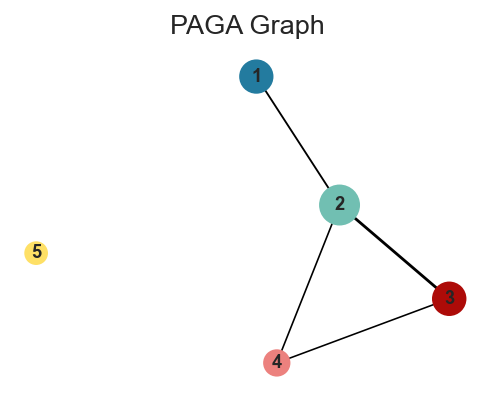

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
sc.pl.paga(
    adata_final,
    color='cca_leiden_clusters',
    threshold=0.11,
    node_size_scale=1.5,
    frameon=False,
    ax=ax,
    show=False
)
ax.set_title('PAGA Graph', fontsize=13)
plt.savefig(fig_dir + "paga_cca_leiden_clusters.pdf", bbox_inches='tight', dpi=300)

In [9]:
# exclude cluster 5 (non-microglia) for downstream pseudotime analysis
# paga proves BAM has no significant connectivity with other clusters
adata_microglia = adata_final[adata_final.obs['cca_leiden_clusters'] != '5'].copy()

In [10]:
sc.pp.neighbors(adata_microglia, n_neighbors=25, use_rep='CCA')

sc.tl.umap(adata_microglia, min_dist=0.5, spread=1.0)

sc.tl.diffmap(adata_microglia)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.98340774 0.9815289  0.96589446 0.94605213 0.93782336
     0.932504   0.92648107 0.9215317  0.90323585 0.89931023 0.89226896
     0.8875556  0.87356395 0.86806846]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


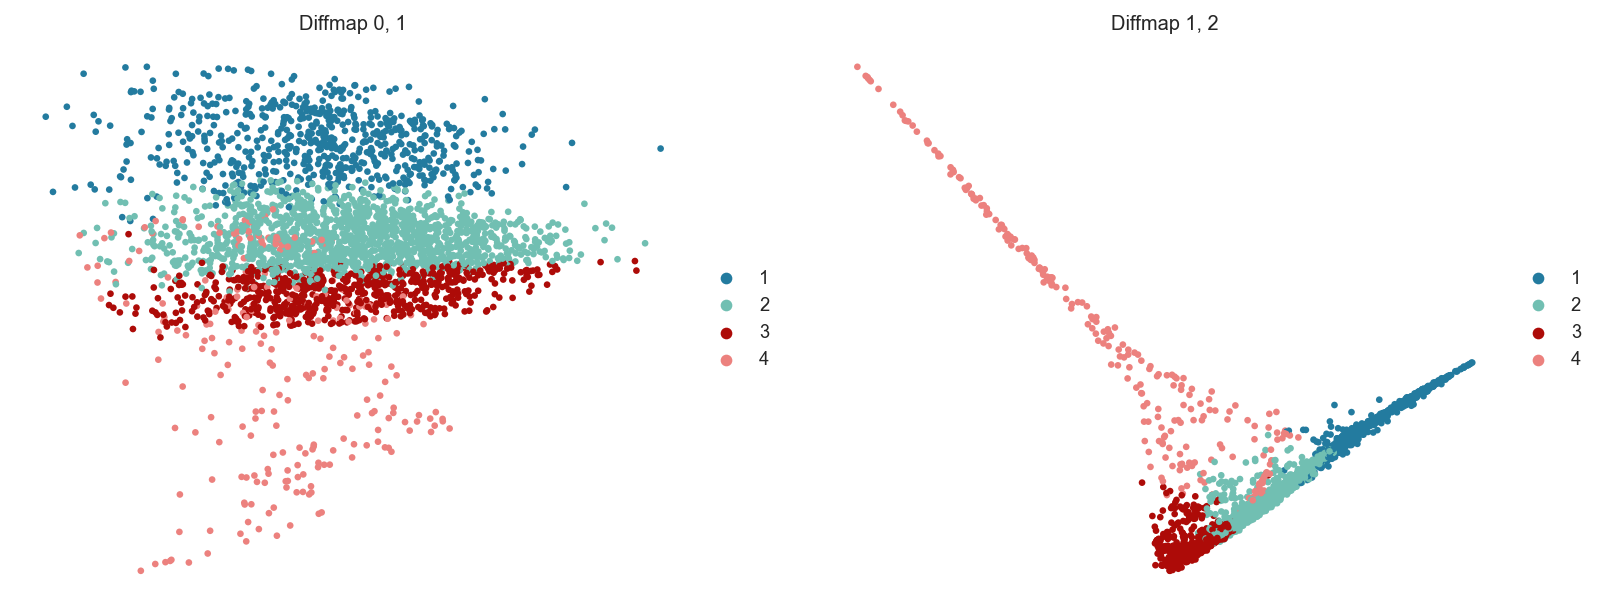

In [11]:
scv.pl.scatter(
    adata_microglia,
    basis="diffmap",
    c='cca_leiden_clusters',
    legend_loc="right",
    title=["Diffmap 0, 1", "Diffmap 1, 2"],  
    components=["0, 1", "1, 2"],
    frameon=False,
    show=False
)
plt.savefig(fig_dir + "diffmap_cca_leiden_clusters.pdf", bbox_inches='tight', dpi=300)

In [12]:
adata_microglia.write(results_dir + "scp_MG_1c_maxlfq_microglia_subset.h5ad", compression='gzip')

In [13]:
adata_microglia = sc.read_h5ad(f"{results_dir}/scp_MG_1c_maxlfq_microglia_subset.h5ad")

### Slingshot

In [14]:
%load_ext rpy2.ipython

In [15]:
%%R
suppressMessages({
    library(anndataR)
    library(ggplot2)
    library(slingshot)
})
setwd('/Users/apple/Desktop/SCP_Projects')

sce <- anndataR::read_h5ad("/Users/apple/Desktop/SCP_Projects/SCP_Microglia/results/2_2_pseudotime_analysis/scp_MG_1c_maxlfq_microglia_subset.h5ad", as = "SingleCellExperiment")

In [16]:
%%R -o crv1 -o crv2 -o pseudotime

sce <- slingshot(sce, clusterLabels = 'cca_leiden_clusters', reducedDim = 'CCA')

pseudotime <- slingPseudotime(sce)

# lineage_weights <- slingCurveWeights(sce)

crvs <- slingCurves(sce)

crv1 <- crvs[[1]]$s
crv2 <- crvs[[2]]$s

In [17]:
pseudotime = np.array(pseudotime, dtype=np.float64)

pseudotime = np.where(np.isnan(pseudotime), np.nan, pseudotime)

In [18]:
np.isnan(pseudotime).sum()

np.int64(711)

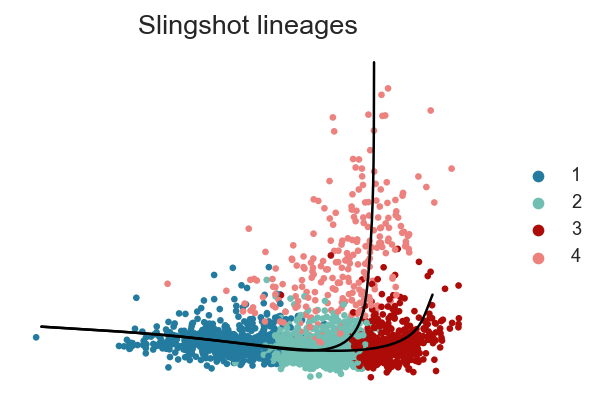

In [19]:
fig, ax = plt.subplots(figsize=(4, 3))

sc.pl.embedding(
    adata_microglia,
    basis='CCA',
    color='cca_leiden_clusters',
    frameon=False,
    ax=ax,
    show=False,
    title='Slingshot lineages'
)
sns.lineplot(x=crv1[:, 0], y=crv1[:, 1], ax=ax, color='black')
sns.lineplot(x=crv2[:, 0], y=crv2[:, 1], ax=ax, color='black')
ax.set_title('Slingshot lineages', fontsize=13)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.05, 0.7))

plt.savefig(fig_dir + "slingshot_lineages_cca_embedding.pdf", bbox_inches='tight', dpi=300)

In [20]:
pseudotime = (pseudotime - np.nanmin(pseudotime, axis=0)) / (np.nanmax(pseudotime, axis=0) - np.nanmin(pseudotime, axis=0))
adata_microglia.obs['slingshot_pseudotime_lineage1'] = pseudotime[:, 0]
adata_microglia.obs['slingshot_pseudotime_lineage2'] = pseudotime[:, 1]

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

for i, lineage in enumerate(['slingshot_pseudotime_lineage1', 'slingshot_pseudotime_lineage2']):
    sc.pl.umap(
        adata_microglia,
        color = lineage,
        frameon=False,
        ax=ax[i],
        show=False,
        title=f'Slingshot pseudotime - lineage {i+1}',
        vmin='p1',
        vmax='p99',
        cmap='viridis'
    )

plt.savefig(fig_dir + "slingshot_pseudotime_umap.pdf", bbox_inches='tight', dpi=300)

### dpt pseudotime

In [22]:
# root_index = adata_microglia.obsm['X_umap'][:, 1].argmax()
root_index = adata_microglia.obsm['X_diffmap'][:, 1].argmax()

adata_microglia.uns['iroot'] = root_index

sc.tl.dpt(adata_microglia)

computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


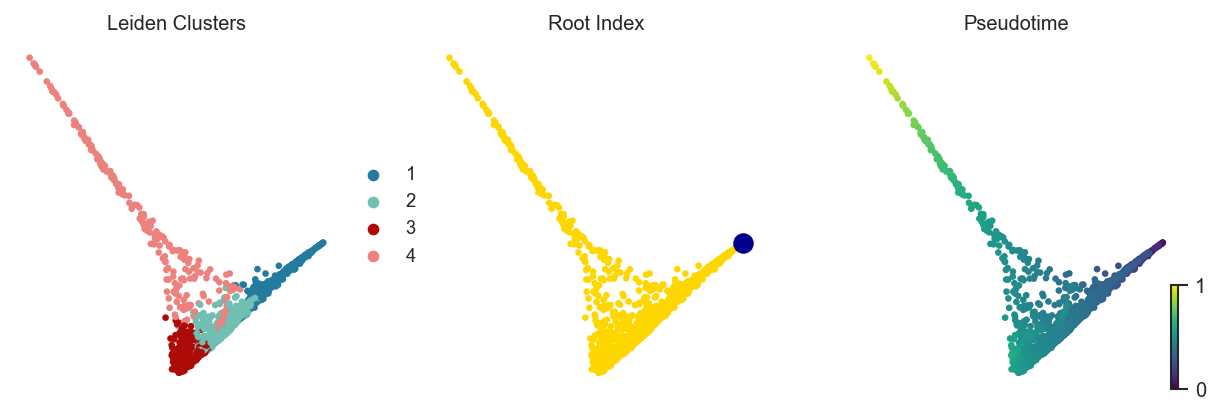

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
title_dict = {
    "cca_leiden_clusters": "Leiden Clusters",
    root_index: "Root Index",
    "dpt_pseudotime": "Pseudotime"
}
for i, parameter in enumerate(["cca_leiden_clusters", root_index, "dpt_pseudotime"]):
    scv.pl.scatter(
        adata_microglia,
        basis="diffmap",
        c=parameter,
        legend_loc="right",
        title=title_dict.get(parameter),
        components=["1, 2"],
        show=False,
        ax=ax[i],
        color_map="viridis" if parameter == "dpt_pseudotime" else None,
        vmax=1 if parameter == "dpt_pseudotime" else None
    )
plt.subplots_adjust(wspace=0.3)
plt.savefig(fig_dir + "dpt_pseudotime_diffmap.png", dpi=300, bbox_inches='tight')

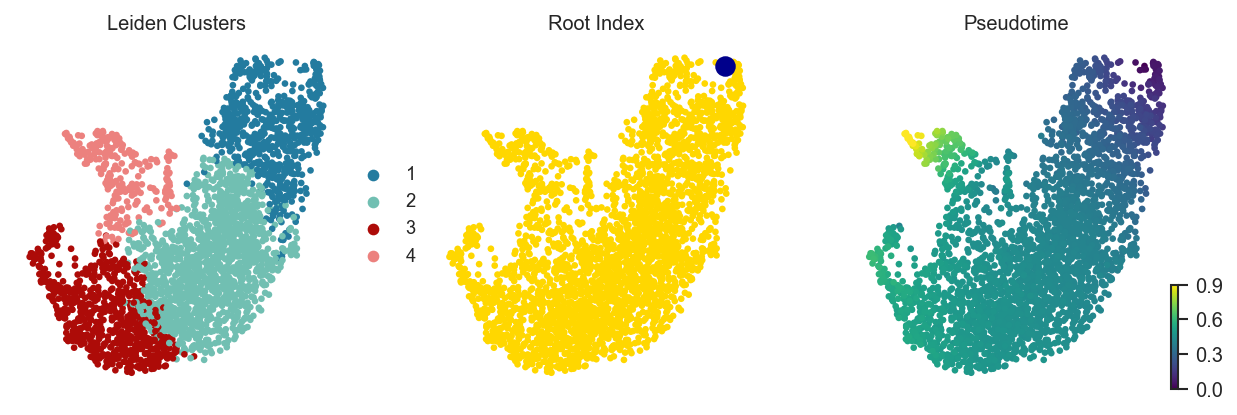

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
title_dict = {
    "cca_leiden_clusters": "Leiden Clusters",
    root_index: "Root Index",
    "dpt_pseudotime": "Pseudotime"
}
for i, parameter in enumerate(["cca_leiden_clusters", root_index, "dpt_pseudotime"]):
    scv.pl.scatter(
        adata_microglia,
        basis="umap",
        c=parameter,
        legend_loc="right",
        title=title_dict.get(parameter),
        components=["1, 2"],
        show=False,
        ax=ax[i],
        color_map="viridis" if parameter == "dpt_pseudotime" else None,
        vmax=0.9 if parameter == "dpt_pseudotime" else None
    )
plt.subplots_adjust(wspace=0.3)
plt.savefig(fig_dir + "dpt_pseudotime_umap.png", dpi=300, bbox_inches='tight')

In [25]:
adata_microglia.obsm['X_umap'] =adata_microglia.obsm['X_umap'].astype(np.float64)

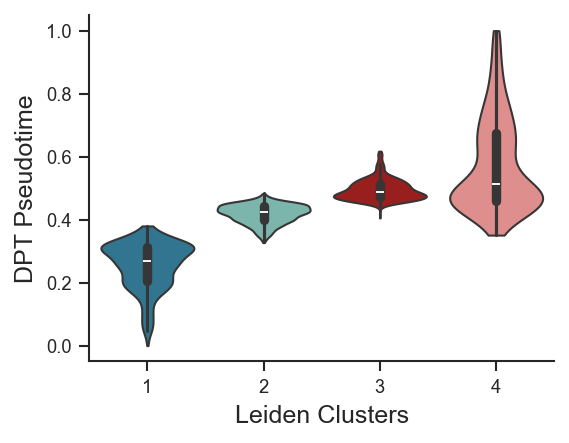

In [26]:
fig, ax = plt.subplots(figsize=(4, 3))
sc.pl.violin(
    adata_microglia,
    keys="dpt_pseudotime",
    groupby="cca_leiden_clusters",
    show=False,
    ax=ax,
    inner='box',
    stripplot=False
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Leiden Clusters", fontsize=12)
plt.ylabel("DPT Pseudotime", fontsize=12)
plt.savefig(fig_dir + "dpt_pseudotime_violin.pdf", dpi=300, bbox_inches='tight')

In [27]:
pseudotime_k = cr.kernels.PseudotimeKernel(adata_microglia, time_key="dpt_pseudotime")
pseudotime_k.compute_transition_matrix()

Computing transition matrix based on pseudotime


100%|██████████| 2933/2933 [00:00<00:00, 11930.15cell/s]

    Finish (0:00:00)


PseudotimeKernel[n=2933, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [28]:
adata_microglia.obsm['X_umap'] = adata_microglia.obsm['X_umap'].astype(np.float32) 

Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:00)


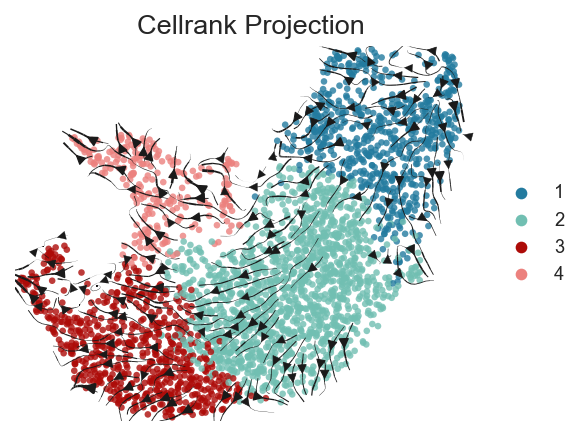

In [29]:
fig, ax = plt.subplots(figsize=(4, 3))

pseudotime_k.plot_projection(
    basis='umap', 
    recompute=True, 
    density=2,     
    color='cca_leiden_clusters', 
    ax=ax, 
    show=False, 
    arrow_size=1,
    legend_loc='center right',
    colorbar=False,
    title=None,
    alpha=0.8,
    size=40
)
ax.set_title('Cellrank Projection', fontsize=13)

plt.tight_layout()
plt.savefig(fig_dir + "cell_rank_projection_umap_cca_leiden_clusters.png", bbox_inches='tight', dpi=300)
plt.show()

In [30]:
pseudotime_g = cr.estimators.GPCCA(pseudotime_k)
pseudotime_g.compute_schur()

Computing Schur decomposition
When computing macrostates, choose a number of states NOT in `[np.int64(8)]`
Adding `adata.uns['eigendecomposition_fwd']`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:01)


GPCCA[kernel=PseudotimeKernel[n=2933], initial_states=None, terminal_states=None]

<Figure size 750x600 with 0 Axes>

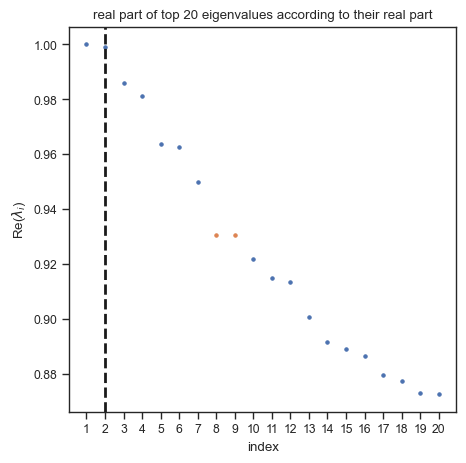

In [31]:
fig = plt.figure(figsize=(5, 4))
pseudotime_g.plot_spectrum(real_only=True)
plt.savefig(fig_dir + "pseudotime_spectrum_global.pdf", dpi=300, bbox_inches='tight')

In [32]:
pseudotime_g.fit(cluster_key="cca_leiden_clusters", n_states=2)

Computing Schur decomposition
Adding `adata.uns['eigendecomposition_fwd']`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:00)
Computing `2` macrostates
Adding `.macrostates`
       `.macrostates_memberships`
       `.coarse_T`
       `.coarse_initial_distribution
       `.coarse_stationary_distribution`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:00)


GPCCA[kernel=PseudotimeKernel[n=2933], initial_states=None, terminal_states=None]

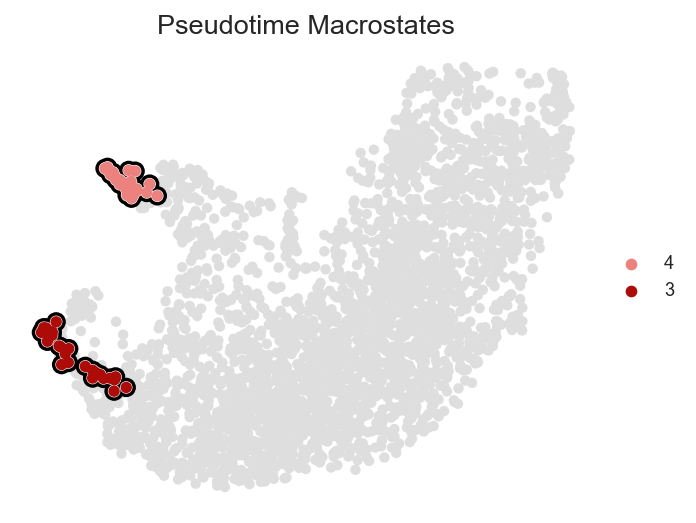

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
pseudotime_g.plot_macrostates(
    which="all", 
    discrete=True,
    frameon=False,
    ax=ax,
    legend_loc="right",
    show=False,
    cmap=None,
    s=100)
ax.set_title('Pseudotime Macrostates', fontsize=13)
plt.savefig(fig_dir + "pseudotime_macrostates_global.pdf", dpi=300, bbox_inches='tight')

In [34]:
pseudotime_g.predict_terminal_states(method='top_n', n_states=2)

Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`


GPCCA[kernel=PseudotimeKernel[n=2933], initial_states=None, terminal_states=[np.str_('3'), np.str_('4')]]

In [ ]:
# fig, ax = plt.subplots(figsize=(5, 4))
fig = plt.figure(figsize=(5, 4))
pseudotime_g.plot_macrostates(
    which="terminal", 
    discrete=False,
    frameon=False,
    legend_loc="right",
    show=False,
    cmap=None,
    same_plot=False,
  )
plt.savefig(fig_dir + "pseudotime_terminal_states_global.pdf", dpi=300, bbox_inches='tight')

In [36]:
pseudotime_g.set_terminal_states(states=["3", "4"])

Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`


GPCCA[kernel=PseudotimeKernel[n=2933], initial_states=None, terminal_states=[np.str_('3'), np.str_('4')]]

In [37]:
pseudotime_g.compute_fate_probabilities()

Computing fate probabilities


100%|██████████| 2/2 [00:00<00:00, 32.24/s]

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:00:00)


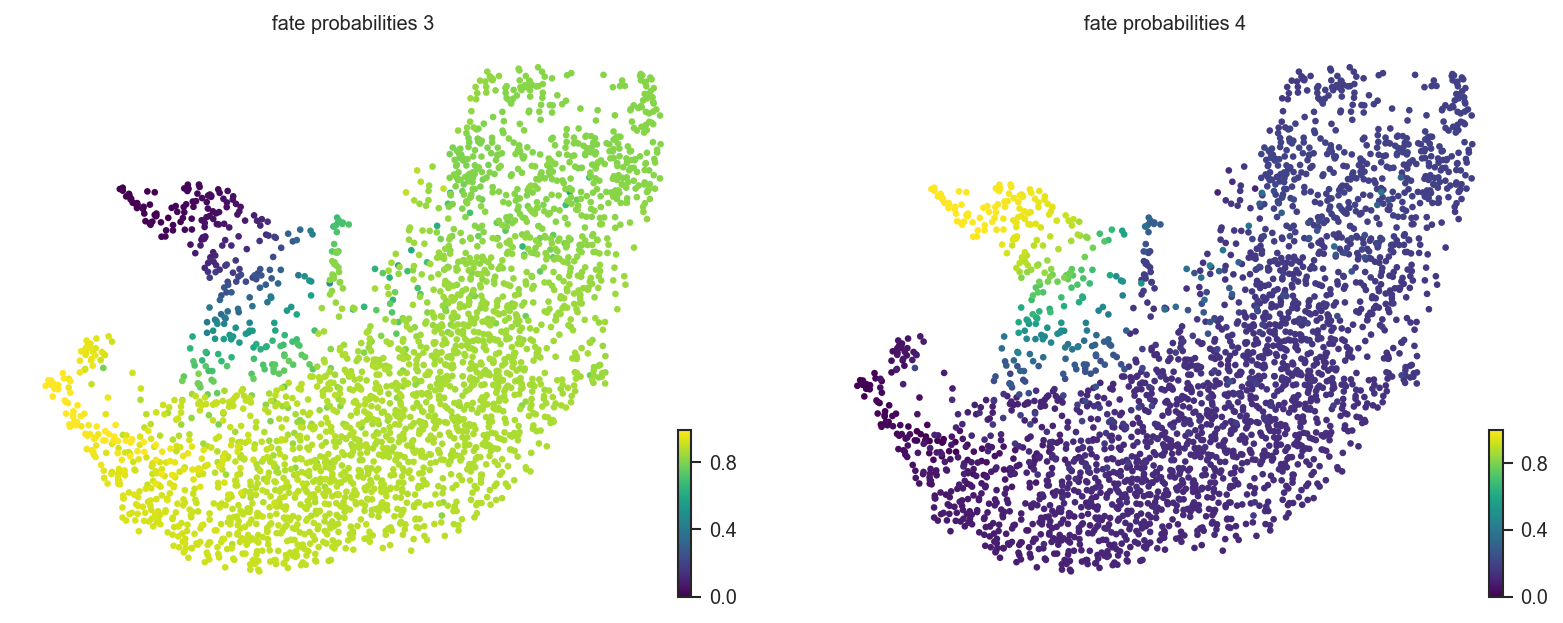

In [38]:
pseudotime_g.plot_fate_probabilities(
    same_plot=False,
    frameon=False,
    show=False,
    )

plt.savefig(fig_dir + "pseudotime_fate_probabilities_global.pdf", dpi=300, bbox_inches='tight')

In [39]:
cluster3_lineage_fwd = np.array(adata_microglia.obsm['lineages_fwd'][:, 0].flatten())
cluster4_lineage_fwd = np.array(adata_microglia.obsm['lineages_fwd'][:, 1].flatten())

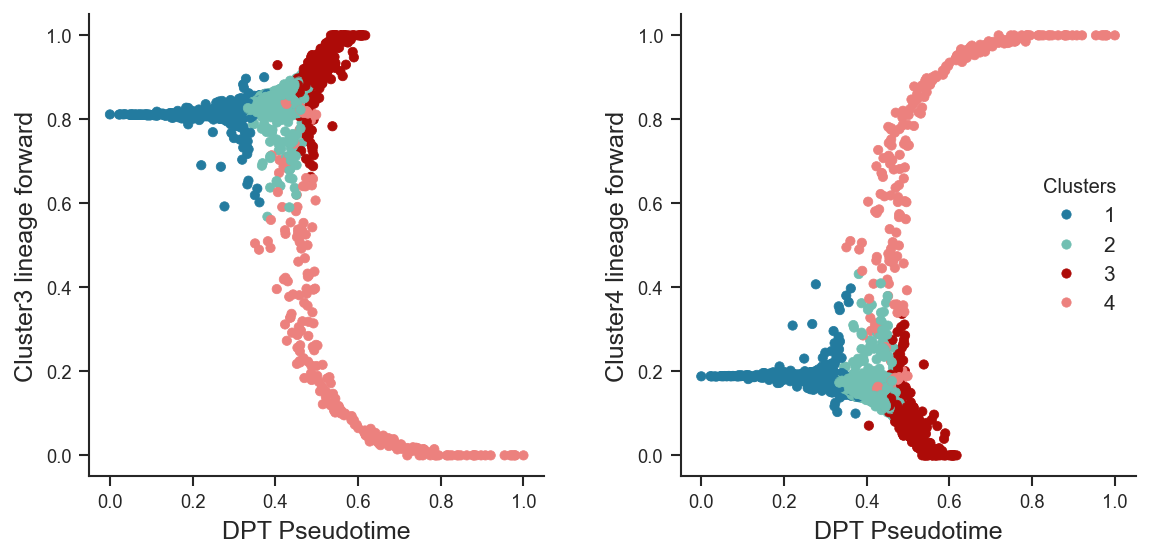

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
sns.scatterplot(
    x = adata_microglia.obs['dpt_pseudotime'],
    y = cluster3_lineage_fwd,
    hue=adata_microglia.obs['cca_leiden_clusters'],
    palette=['#237B9F', '#71BFB2', '#AD0B08', '#EC817E'],
    ax=ax[0],
    edgecolor=None,
    s=20,
    legend=False
)

ax[0].set_ylabel('Cluster3 lineage forward', fontsize=12)
ax[0].set_xlabel('DPT Pseudotime', fontsize=12)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

sns.scatterplot(
    x = adata_microglia.obs['dpt_pseudotime'],
    y = cluster4_lineage_fwd,
    hue=adata_microglia.obs['cca_leiden_clusters'],
    palette=['#237B9F', '#71BFB2', '#AD0B08', '#EC817E'],
    ax=ax[1],
    edgecolor=None,
    s=20
)
ax[1].legend(frameon=False, title='Clusters', loc='center right', fontsize=10)
ax[1].set_ylabel('Cluster4 lineage forward', fontsize=12)
ax[1].set_xlabel('DPT Pseudotime', fontsize=12)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.subplots_adjust(wspace=0.3)

plt.savefig(fig_dir + "lineages_fwd_dpt_pseudotime_scatter.pdf", bbox_inches='tight', dpi=300)

In [41]:
model_global = cr.models.GAM(
    adata_microglia,
    distribution='normal',
    link='log',
)

Computing trends using `1` core(s)


100%|██████████| 4/4 [00:00<00:00, 26.68gene/s]

    Finish (0:00:00)
Plotting trends


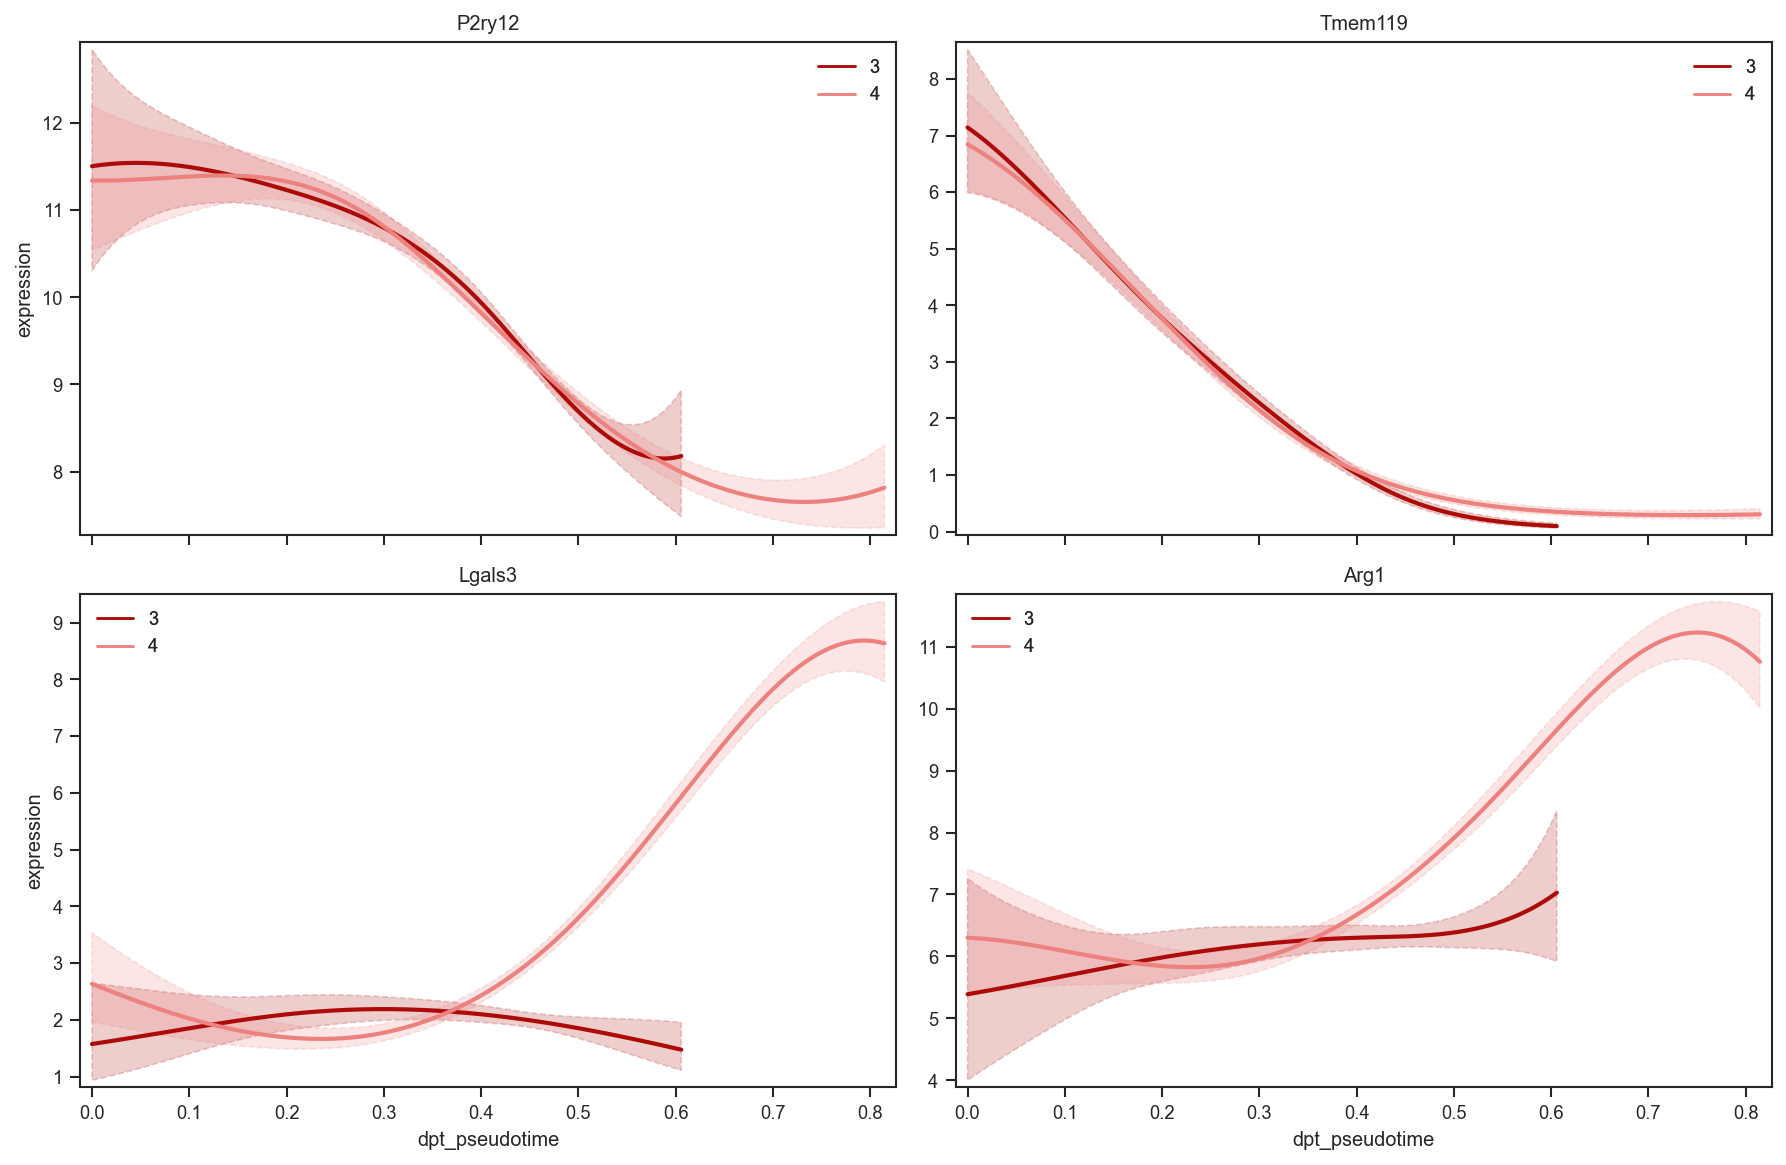

In [42]:
model = cr.pl.gene_trends(
        adata_microglia,
        model=model_global,
        genes=["P2ry12", "Tmem119", "Lgals3", "Arg1"],
        same_plot=True,
        time_key="dpt_pseudotime",
        hide_cells=True,
        data_key="log2_total_normalized",
        return_models=True,
        return_figure=False
        # lineage_cmap = ["#ACD6EC", "#F5A889"]
    )

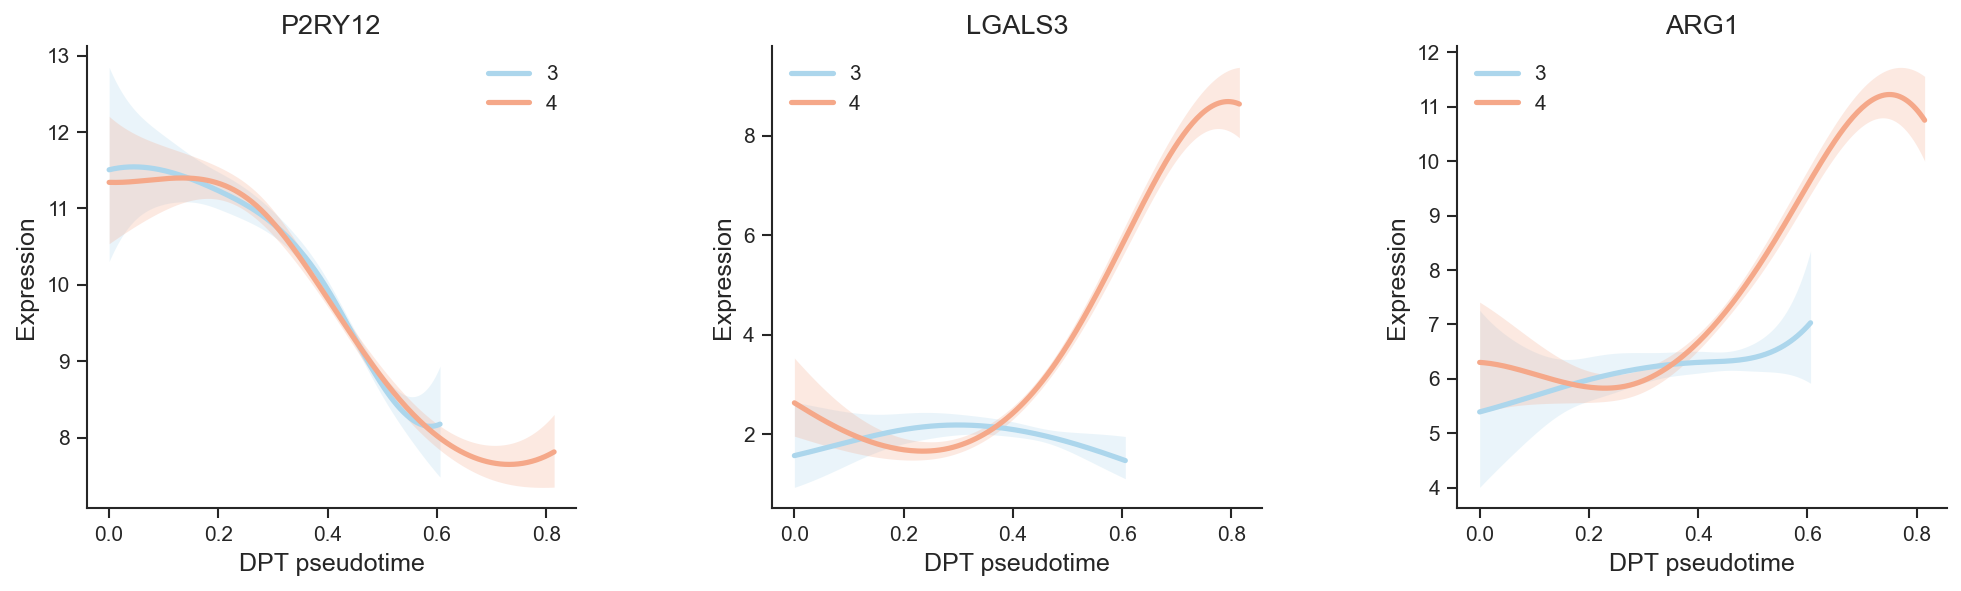

In [43]:
lineage_colors = {
    "3": "#ACD6EC",
    "4": "#F5A889",
}

genes = ['P2ry12', 'Lgals3', 'Arg1']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes = axes.flatten()

for i, gene in enumerate(genes):

    for lineage, m in model[gene].items():
        x = np.ravel(m.x_test)
        y = np.ravel(m.y_test)

        color = lineage_colors.get(lineage, "black")

        axes[i].plot(
            x,
            y,
            color=color,
            lw=2.5,
            label=lineage
        )

        if getattr(m, "conf_int", None) is not None:
            ci = np.asarray(m.conf_int)
            axes[i].fill_between(
                x,
                ci[:, 0],
                ci[:, 1],
                color=color,
                alpha=0.25,
                linewidth=0
            )

        axes[i].set_title(gene.upper(), fontsize=13)
        axes[i].set_xlabel("DPT pseudotime", fontsize=12)
        axes[i].set_ylabel("Expression", fontsize=12)

        axes[i].tick_params(axis="both", labelsize=10)
        axes[i].legend(frameon=False, fontsize=10)

        for spine in ["top", "right"]:
            axes[i].spines[spine].set_visible(False)

plt.subplots_adjust(wspace=0.4)
plt.savefig(fig_dir + "gene_trends_dpt_pseudotime.pdf", dpi=300, bbox_inches='tight')